# Decision Tree Classification

## Load the dataset iris

In [1]:
from sklearn.datasets import load_iris

iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

## Declare X, y
X: independent variables, the features/attributes used for classification prediction
y: dependent variables, the feature/attribute/target used for training and testing

In [2]:
X = iris.data
y = iris.target

## Prepare stages
training and testing dataset are splited with test_size as ratio.
Here we use 80% for training and 20% for testing

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

## Train your model

In [4]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier()
classifier.fit(X_train, y_train)

DecisionTreeClassifier()

Evaluate your model

In [5]:
y_pred = classifier.predict(X_test)

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 7  0  0]
 [ 0  8  5]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.62      0.76        13
           2       0.67      1.00      0.80        10

    accuracy                           0.83        30
   macro avg       0.89      0.87      0.85        30
weighted avg       0.89      0.83      0.83        30



## Visualize the result

In [7]:
from sklearn import tree

text_representation = tree.export_text(classifier)
print(text_representation)

|--- feature_3 <= 0.75
|   |--- class: 0
|--- feature_3 >  0.75
|   |--- feature_3 <= 1.55
|   |   |--- feature_2 <= 4.95
|   |   |   |--- class: 1
|   |   |--- feature_2 >  4.95
|   |   |   |--- class: 2
|   |--- feature_3 >  1.55
|   |   |--- class: 2



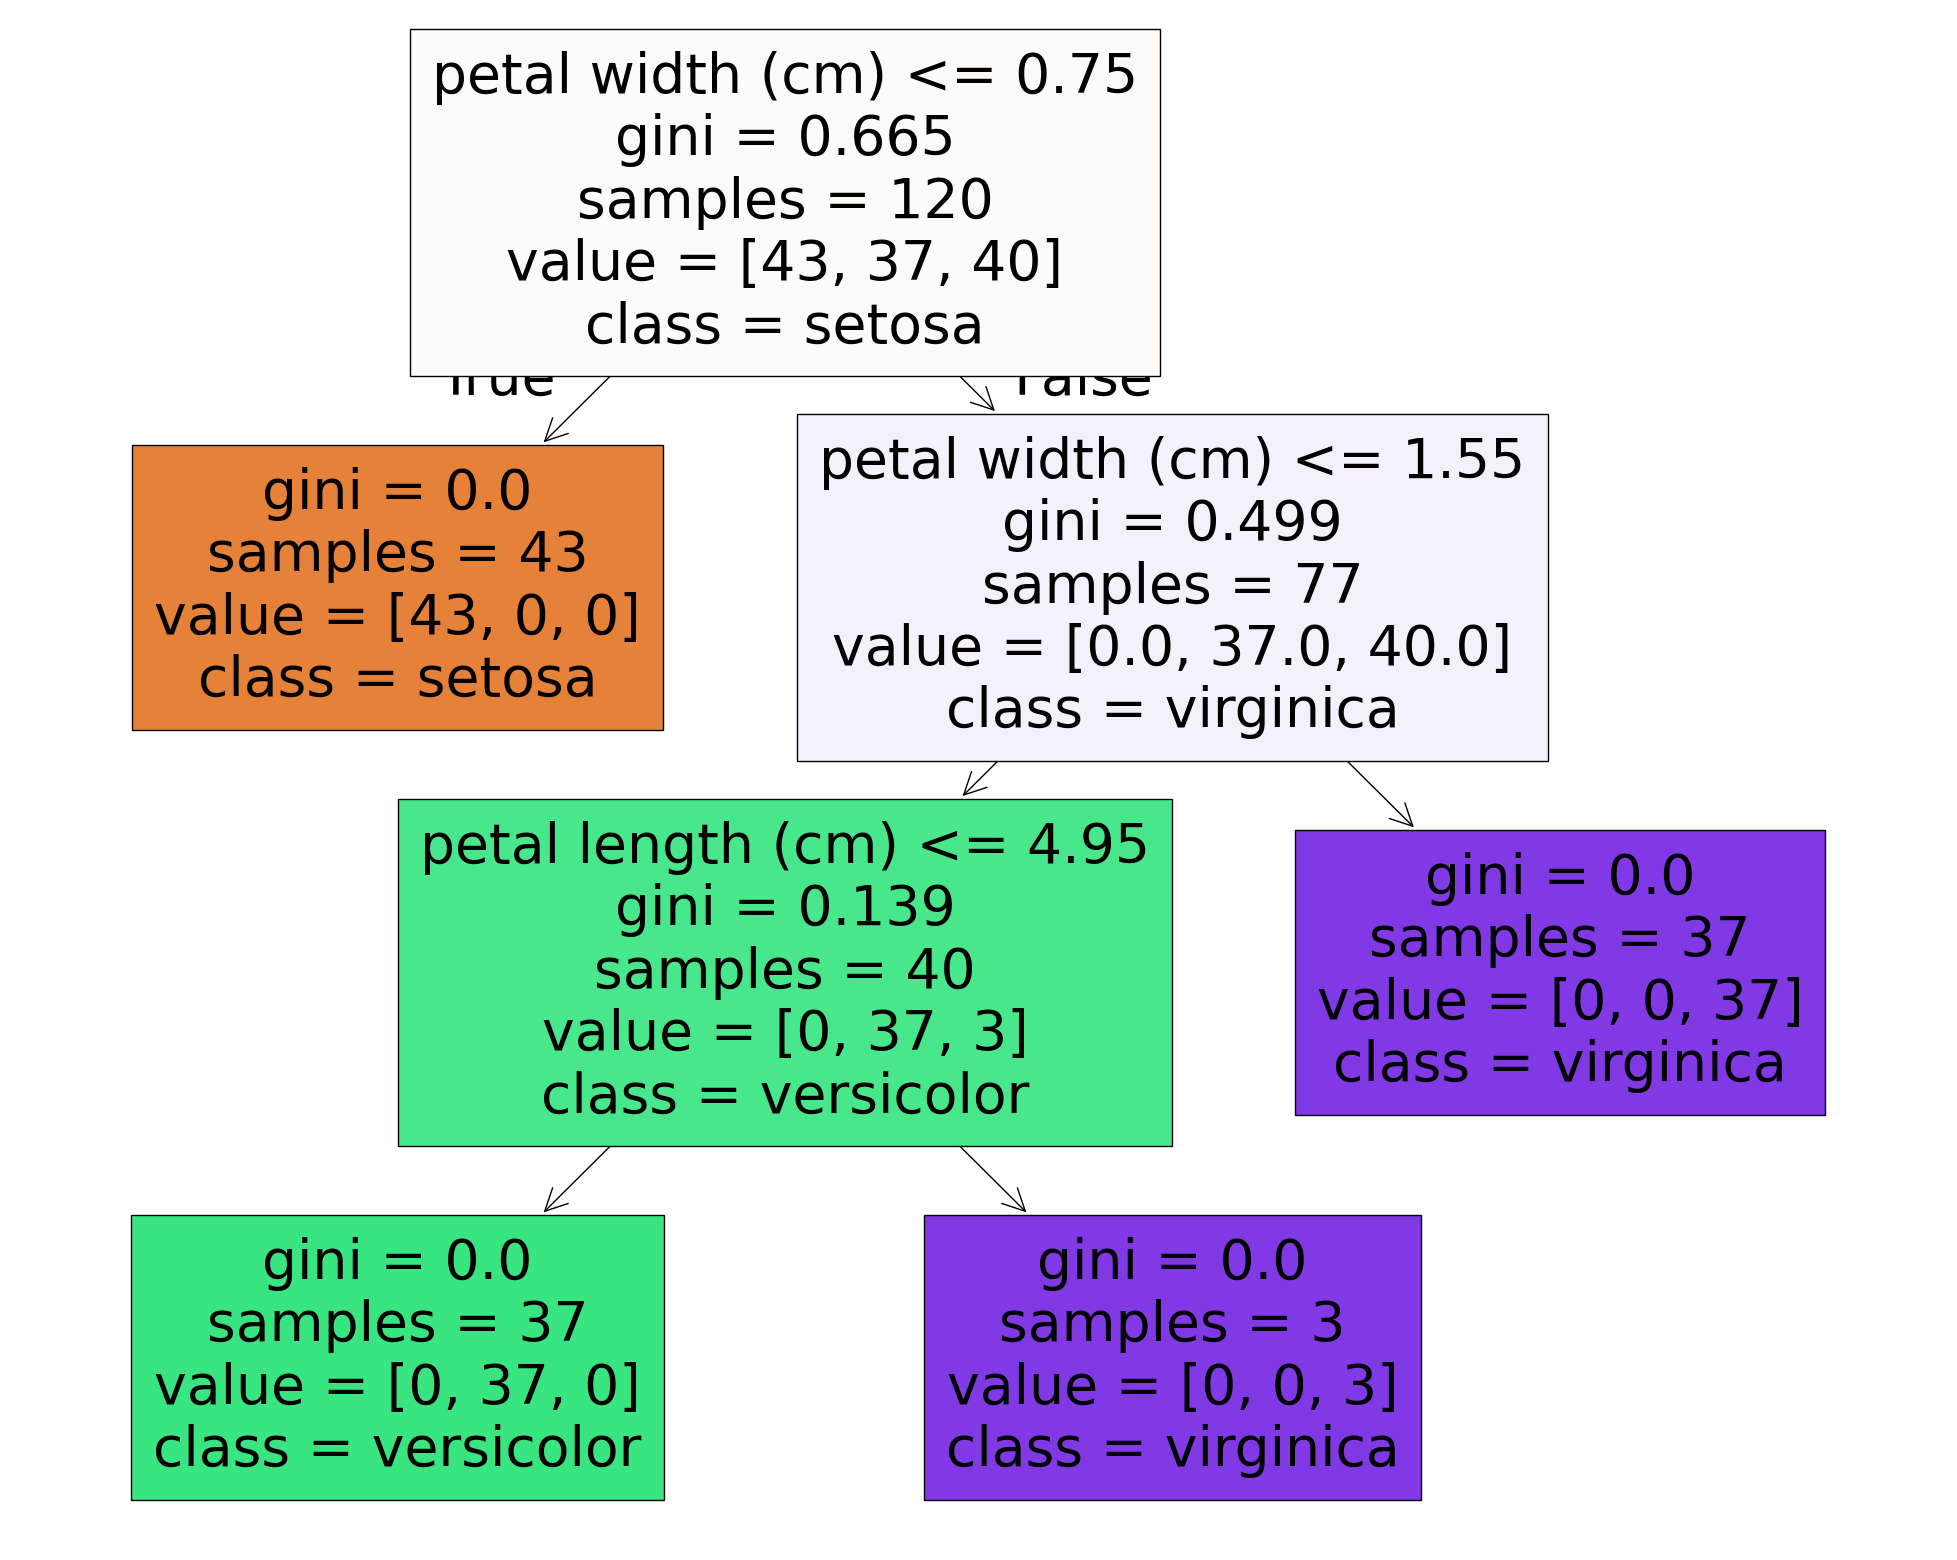

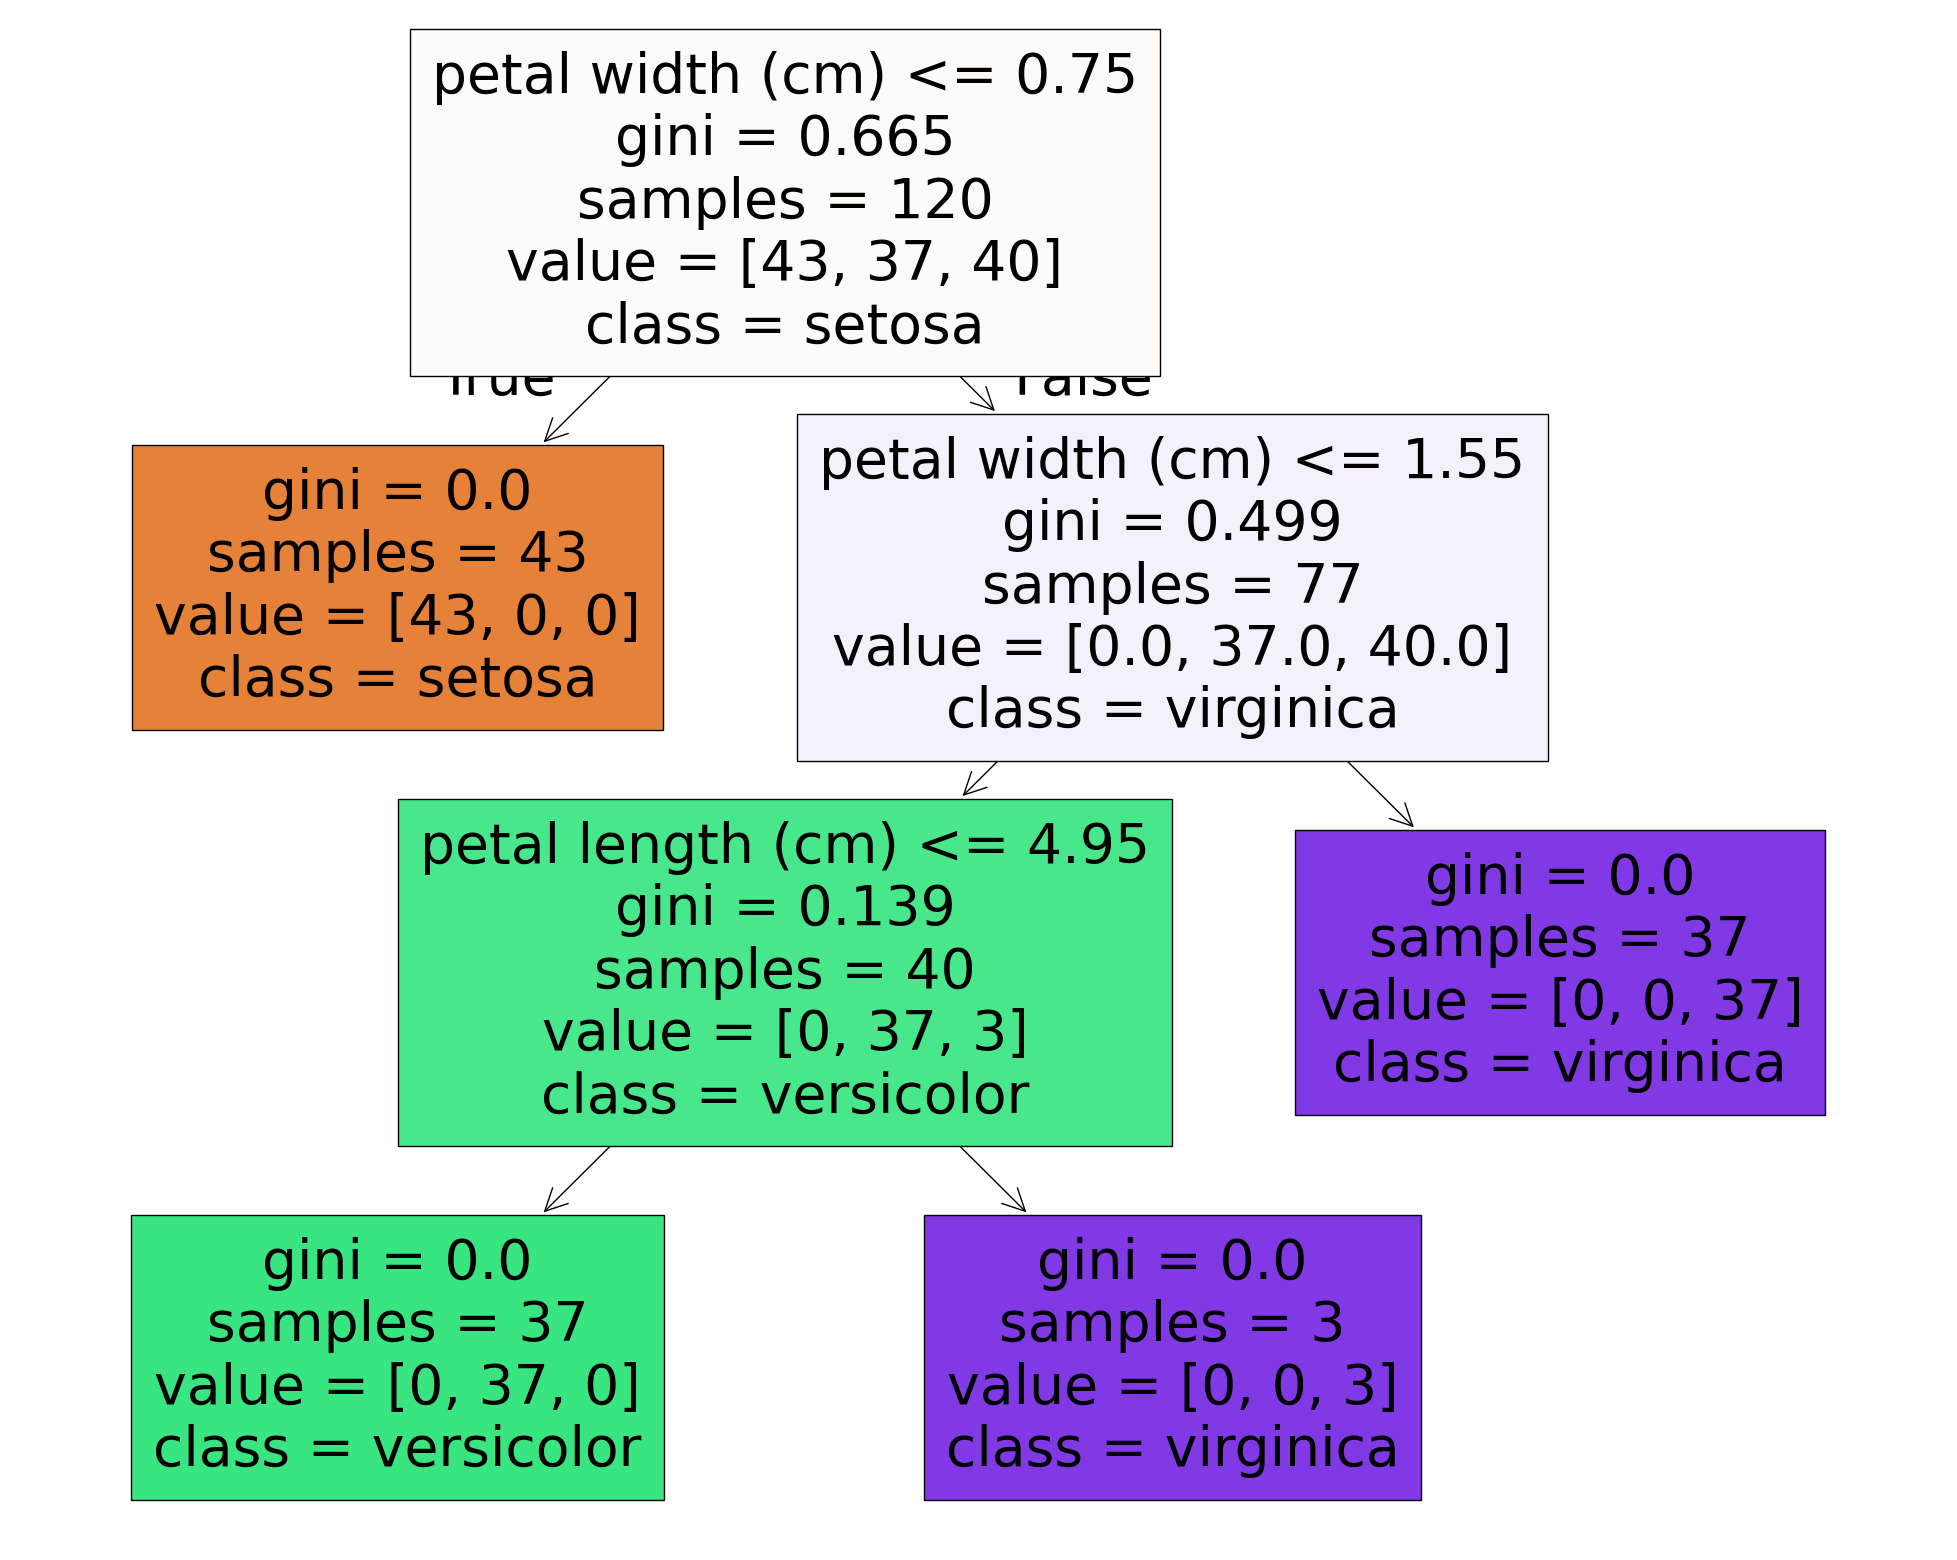

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(classifier, 
                   feature_names=iris.feature_names,  
                   class_names=iris.target_names,
                   filled=True)
plt.show()

## Tune the model

Change hyperparameters, such as criterion, max_depth

In [10]:
classifier = DecisionTreeClassifier(criterion= 'entropy')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

text_representation = tree.export_text(classifier)
print(text_representation)

fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(classifier, 
                   feature_names=iris.feature_names,  
                   class_names=iris.target_names,
                   filled=True)

[[ 7  0  0]
 [ 0  8  5]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.62      0.76        13
           2       0.67      1.00      0.80        10

    accuracy                           0.83        30
   macro avg       0.89      0.87      0.85        30
weighted avg       0.89      0.83      0.83        30

|--- feature_3 <= 0.75
|   |--- class: 0
|--- feature_3 >  0.75
|   |--- feature_3 <= 1.55
|   |   |--- feature_2 <= 4.95
|   |   |   |--- class: 1
|   |   |--- feature_2 >  4.95
|   |   |   |--- class: 2
|   |--- feature_3 >  1.55
|   |   |--- class: 2



In [11]:
classifier = DecisionTreeClassifier(max_depth=3)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

text_representation = tree.export_text(classifier)
print(text_representation)

fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(classifier, 
                   feature_names=iris.feature_names,  
                   class_names=iris.target_names,
                   filled=True)

[[ 7  0  0]
 [ 0  8  5]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.62      0.76        13
           2       0.67      1.00      0.80        10

    accuracy                           0.83        30
   macro avg       0.89      0.87      0.85        30
weighted avg       0.89      0.83      0.83        30

|--- feature_3 <= 0.75
|   |--- class: 0
|--- feature_3 >  0.75
|   |--- feature_3 <= 1.55
|   |   |--- feature_2 <= 4.95
|   |   |   |--- class: 1
|   |   |--- feature_2 >  4.95
|   |   |   |--- class: 2
|   |--- feature_3 >  1.55
|   |   |--- class: 2



## Credit

*   https://scikit-learn.org/stable/modules/tree.html
*   https://mljar.com/blog/visualize-decision-tree/


Decisition Tree by Di Wu is licensed under [CC BY NC SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).